[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day2/06_forward_prediction.ipynb)

# Day 2, Afternoon: Sequence to Structure with RNNs

**Today's topics:**
* The forward problem: learning MD as a cheap surrogate
* Encoding polymer sequences (and why order matters)
* Recurrent networks and the GRU cell
* Training and honestly evaluating the forward model

*Where are we?*

Notebooks 04-05 turned simulation snapshots into a 2-D structure map $z \in \mathbb{R}^2$.
Today we learn the map $f: s \to \hat z$ straight from the sequence, no simulation required at prediction time.

Notation, one more time (defined in notebook 01, reused everywhere).
A sequence is $s \in \{A, B\}^{10}$, stored as a length-10 string of `'0'` (A) and `'1'` (B).
Notebook 03 turned each simulated structure into a fingerprint $x \in \mathbb{R}^{1280}$.
Notebook 04 fit a PCA map from a 64-sequence sample, and notebook 05 walked its `.transform()` by hand, embedding fingerprints into latent coordinates $z \in \mathbb{R}^2$ (columns `z0`, `z1`).
The **oracle** that produced $z$ is MD plus featurization plus embedding: slow and expensive.
This notebook builds the **surrogate** $f: s \to \hat z$ (`model`), which skips straight from the string to the coordinates.

## Where this comes from

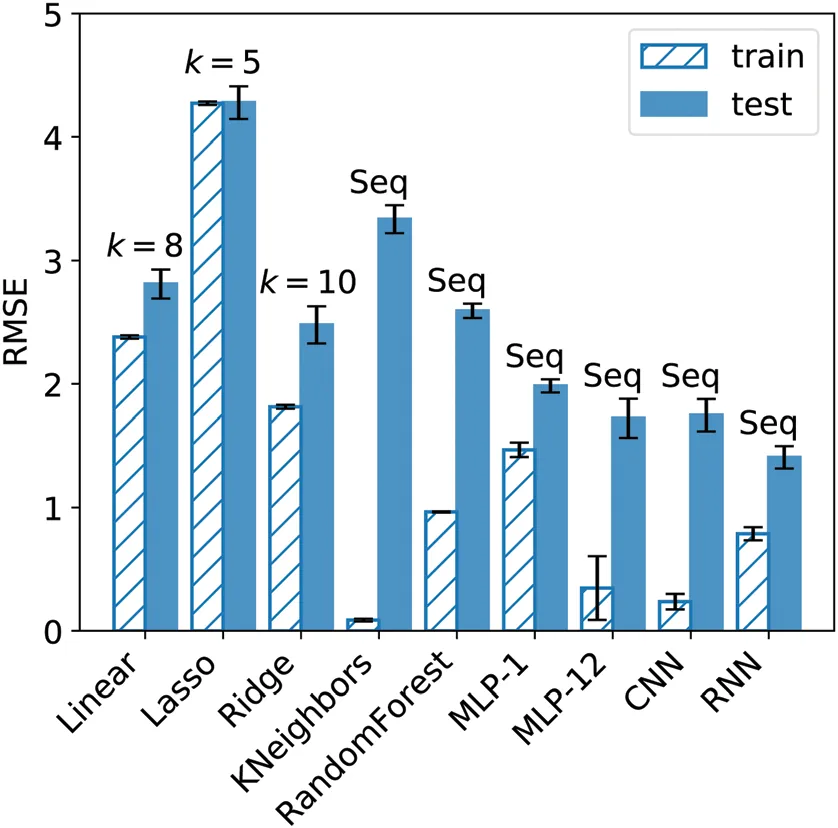

*Fig. 7: Bhattacharya, Kleeblatt, Statt & Reinhart, Soft Matter **18**, 5037 (2022). [doi.org/10.1039/d2sm00452f](https://doi.org/10.1039/d2sm00452f)*

Nine architectures were compared on this sequence-to-morphology task.
The best model was a recurrent network reading the raw sequence, ahead of the hand-counted k-mer representations.

That is why this notebook trains a GRU rather than extending the k-mer regression you met in notebook 03.

We won't reproduce all nine bars.
We test the paper's key lesson locally: does a held-out GRU beat a composition-only baseline on this smaller dataset?

This notebook is an outline of the session: the topics above and the published work it builds on.
The complete notebook, with its code and exercises, will be posted before the workshop begins on August 7.